In [1]:
%pip install torch torchaudio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from moviepy import VideoFileClip

# 1. 모델 로드
model, utils = torch.hub.load(repo_or_dir='snakers4/silero-vad', model='silero_vad')
(get_speech_timestamps, _, _, _, _) = utils

def run_interview_analysis(video_path):
    audio_path = "dummy.wav"
    
    # 오디오 추출 (최신 moviepy v2.0+ 문법 적용)
    with VideoFileClip(video_path) as clip:
        if clip.audio is None:
            print("❌ 오류: 영상에 오디오 트랙이 없습니다.")
            return
        
        # 'verbose'와 'logger' 인자 문제를 해결한 부분입니다.
        # logger=None으로 설정하면 불필요한 로그 메시지를 끕니다.
        clip.audio.write_audiofile(
            audio_path, 
            fps=16000, 
            codec='pcm_s16le', 
            logger=None  # verbose=False 대신 logger=None 사용
        )

    # [2] 데이터 로드 및 VAD 분석
    y, sr = librosa.load(audio_path, sr=16000)
    wav_tensor = torch.from_numpy(y)
    speech_timestamps = get_speech_timestamps(wav_tensor, model, sampling_rate=16000, threshold=0.5)

    # [3] 시각화
    plt.figure(figsize=(15, 6))
    
    # 기본 파형 그리기
    librosa.display.waveshow(y, sr=sr, alpha=0.3, color='gray')
    
    # 전체 시간을 빨간색(정적)으로 먼저 채우기
    plt.axvspan(0, len(y)/sr, color='red', alpha=0.1, label='Silence/Hesitation')
    
    # 음성 구간(말하는 중)만 초록색으로 덮어씌우기
    for ts in speech_timestamps:
        start = ts['start'] / 16000
        end = ts['end'] / 16000
        plt.axvspan(start, end, color='green', alpha=0.3, label='Speech' if ts == speech_timestamps[0] else "")

    plt.title(f"Interview Pacing Analysis: {video_path.split('/')[-1]}", fontsize=15)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

    # 결과 요약
    total_duration = len(y) / sr
    speech_duration = sum([(ts['end'] - ts['start']) / 16000 for ts in speech_timestamps])
    silence_duration = total_duration - speech_duration
    
    print(f"▶ 총 영상 길이: {total_duration:.2f}초")
    print(f"▶ 실제 발화 시간: {speech_duration:.2f}초")
    print(f"▶ 정적(머뭇거림) 시간: {silence_duration:.2f}초")

Using cache found in C:\Users\user/.cache\torch\hub\snakers4_silero-vad_master


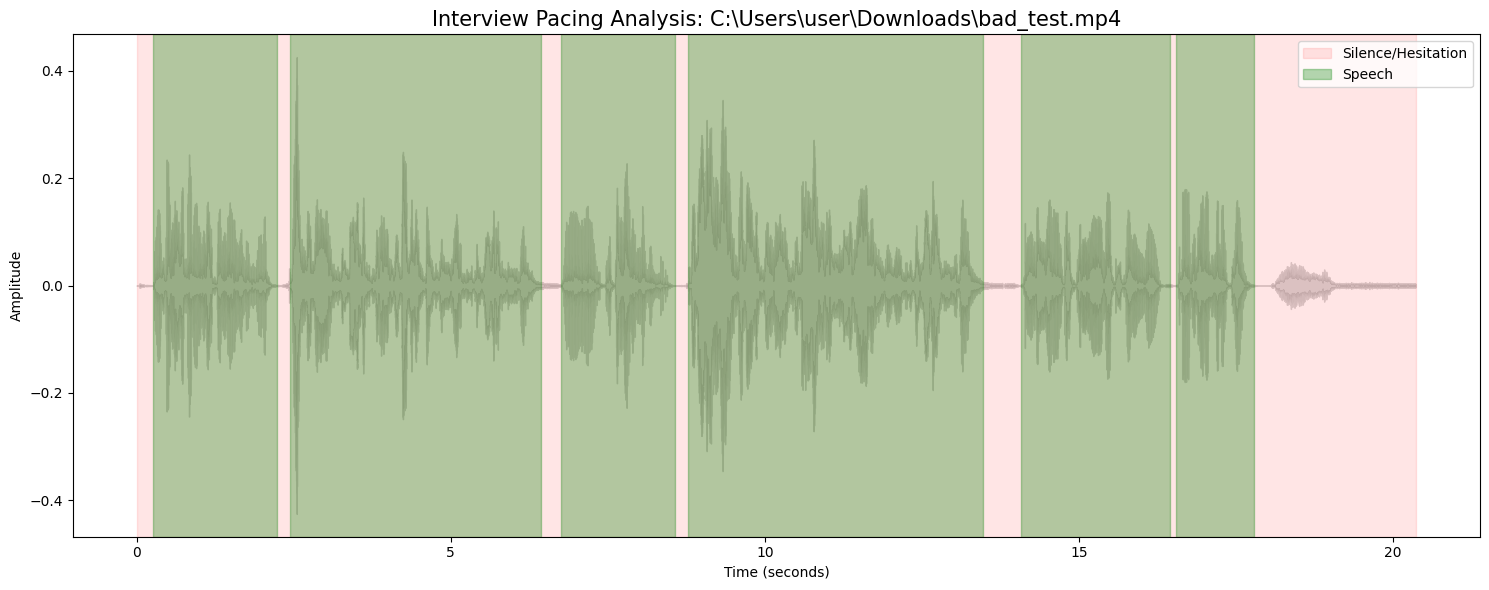

▶ 총 영상 길이: 20.37초
▶ 실제 발화 시간: 16.10초
▶ 정적(머뭇거림) 시간: 4.27초


In [ ]:
video_path = r"C:\Users\user\Downloads\bad_test.mp4"
run_interview_analysis(video_path)

In [4]:
# 어디서 말을 잘 못하는지 확인.

def detail_analysis_silero(video_path):
    audio_path = "dummy.wav"
    
    with VideoFileClip(video_path) as clip:
        if clip.audio is None: return
        clip.audio.write_audiofile(audio_path, fps=16000, codec='pcm_s16le', logger=None)

    y, sr = librosa.load(audio_path, sr=16000)
    wav_tensor = torch.from_numpy(y)
    speech_ts = get_speech_timestamps(wav_tensor, model, sampling_rate=16000, threshold=0.5)

    total_duration = len(y) / sr
    silence_intervals = []

    # 1. 첫 마디 시작 전 정적 확인
    if speech_ts and (speech_ts[0]['start'] / 16000) > 0.1:
        silence_intervals.append((0, speech_ts[0]['start'] / 16000))

    # 2. 문장 사이 정적 계산
    for i in range(len(speech_ts) - 1):
        pause_start = speech_ts[i]['end'] / 16000
        pause_end = speech_ts[i+1]['start'] / 16000
        if pause_end - pause_start > 0.1: # 0.1초 이상의 공백만 기록
            silence_intervals.append((pause_start, pause_end))

    # 3. 마지막 말 이후 정적 확인
    if speech_ts and (speech_ts[-1]['end'] / 16000) < total_duration - 0.1:
        silence_intervals.append((speech_ts[-1]['end'] / 16000, total_duration))

    # 시각화
    plt.figure(figsize=(15, 5))
    librosa.display.waveshow(y, sr=sr, alpha=0.3, color='gray')
    
    for start, end in silence_intervals:
        plt.axvspan(start, end, color='red', alpha=0.2)

    plt.title("Detected Silence Intervals (Red Zones)")
    plt.xlabel("Time (s)")
    plt.show()

    print(f"\n===== [정적 구간 상세 목록] =====")
    for i, (s, e) in enumerate(silence_intervals):
        print(f"{i+1}번째 정적: {s:.2f}초 ~ {e:.2f}초 (길이: {e-s:.2f}초)")
    
    speech_duration = sum([(ts['end'] - ts['start']) / 16000 for ts in speech_ts])
    print(f"\n총 영상: {total_duration:.2f}s | 발화: {speech_duration:.2f}s | 정적 합계: {total_duration - speech_duration:.2f}s")

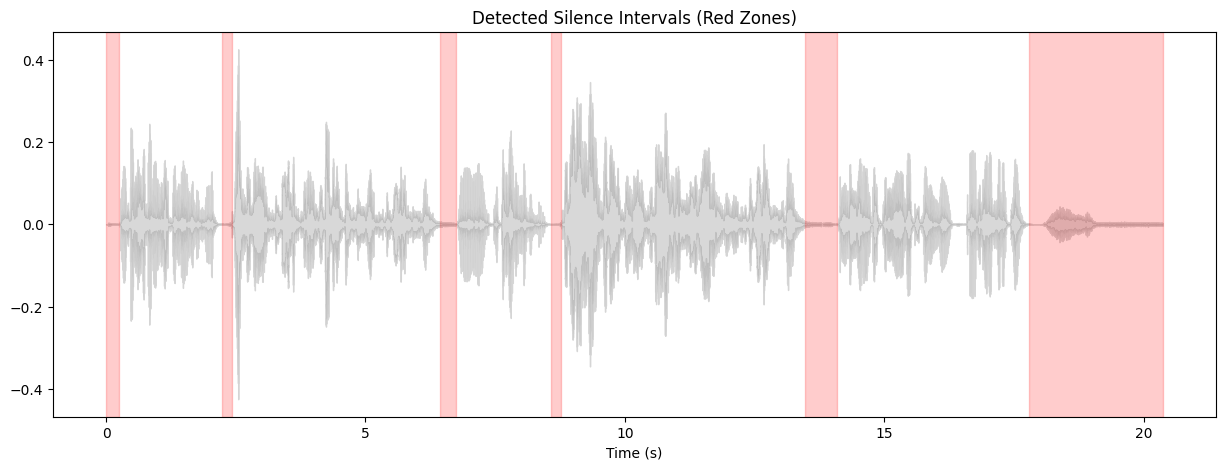


===== [정적 구간 상세 목록] =====
1번째 정적: 0.00초 ~ 0.26초 (길이: 0.26초)
2번째 정적: 2.24초 ~ 2.43초 (길이: 0.20초)
3번째 정적: 6.43초 ~ 6.75초 (길이: 0.32초)
4번째 정적: 8.57초 ~ 8.77초 (길이: 0.20초)
5번째 정적: 13.47초 ~ 14.08초 (길이: 0.61초)
6번째 정적: 17.79초 ~ 20.37초 (길이: 2.58초)

총 영상: 20.37s | 발화: 16.10s | 정적 합계: 4.27s


In [ ]:
video_path = r"C:\Users\user\Downloads\bad_test.mp4"
detail_analysis_silero(video_path)